# RAG Chatbot with LangSmith Tracing

This notebook walks through building a Retrieval-Augmented Generation (RAG) chatbot from scratch, using Paestum and the Cilento coast (Italy) as the example knowledge domain.

**What you'll learn:**
- How to load documents from different formats (Wikipedia, `.docx`, `.pdf`, `.txt`) into a common pipeline
- How embeddings and a vector store let you search documents by *meaning* rather than exact keywords
- How to assemble a RAG chain with LangChain's LCEL (`|` pipe) syntax
- Why a plain RAG chain has no memory of previous turns, and how to add conversational memory
- How LangSmith fits in to trace and debug each step of the pipeline

Shared helper functions used throughout (`split_and_import`, `execute_chain`, `execute_chain_with_memory`, `get_chat_history_messages`) live in `utils.py` so the notebook cells stay focused on the concepts rather than plumbing.

In [1]:
from langchain_community.document_loaders import (
    WikipediaLoader,
    Docx2txtLoader,
    PyPDFLoader,
    TextLoader,
    DirectoryLoader,
)
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_community.chat_message_histories import ChatMessageHistory
from IPython.display import Image, display
import wikipedia

from utils import (
    llm,
    split_and_import,
    execute_chain)
    

/var/folders/l9/yy4p2mt57pgd6xg81cpj9m9cd7vrkr/T/ipykernel_59650/1930680303.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (
/Users/bahloulia/Downloads/agentic_software/RAG-Applications/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set up embeddings and vector store

Before we can retrieve anything, we need a place to store documents in a way that supports *semantic* search.

- **Text splitter**: LLMs and embedding models work best on small chunks of text, not entire documents. `RecursiveCharacterTextSplitter` breaks documents into ~500-character pieces. `chunk_overlap=0` means chunks don't share text with their neighbors — fine for this example, though in practice a small overlap (e.g. 50-100 chars) can help preserve context that falls on a chunk boundary.
- **Embeddings model**: `all-MiniLM-L6-v2` turns each chunk of text into a vector (a list of numbers) that captures its meaning. Chunks with similar meaning end up with similar vectors, which is what makes semantic search possible.
- **Vector store**: `Chroma` stores those vectors alongside the original text and metadata, and lets us later ask "which stored chunks are most similar to this query?"

We also set a custom Wikipedia user agent — Wikipedia's API now blocks the default `python-wikipedia` client, so we identify ourselves with a real contact string instead.

In [2]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=0)
embeddings_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_db = Chroma("tourist_info", embeddings_model)

# Wikipedia now rate-limits/blocks the default python-wikipedia User-Agent (429).
# Identify the client with a real contact per https://w.wiki/4wJS.
wikipedia.set_user_agent("RAG-Applications/1.0 (amine.bahlouli1993@gmail.com)")

## Ingest source documents

"Ingesting" a document means: load it, split it into chunks, embed those chunks, and store them in the vector database. The `split_and_import` helper (in `utils.py`) does exactly that for any LangChain document loader.

We use a different loader per file format — Wikipedia, Word, PDF, and plain text — but they all funnel through the same `split_and_import` function, which is the point of using a common `Document` interface: the rest of the pipeline doesn't need to know or care where a chunk originally came from.

Next, we ingest an entire folder of mixed-format tourist info files at once using `DirectoryLoader`. Note that `glob` doesn't support brace syntax like `"**/*.{docx,pdf,txt}"`, so we run one `DirectoryLoader` per extension instead.

In [3]:
wikipedia_loader = WikipediaLoader(query="Paestum")
split_and_import(wikipedia_loader, text_splitter, vector_db)

word_loader = Docx2txtLoader("../Paestrum/Paestum-Britannica.docx")
split_and_import(word_loader, text_splitter, vector_db)

pdf_loader = PyPDFLoader("../Paestrum/PaestumRevisited.pdf")
split_and_import(pdf_loader, text_splitter, vector_db)

txt_loader = TextLoader("../Paestrum/Paestum-Encyclopedia.txt")
split_and_import(txt_loader, text_splitter, vector_db)

/Users/bahloulia/Downloads/agentic_software/RAG-Applications/.venv/lib/python3.11/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /Users/bahloulia/Downloads/agentic_software/RAG-Applications/.venv/lib/python3.11/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Ingested chunks created by <langchain_community.document_loaders.wikipedia.WikipediaLoader object at 0x13552df10>
Ingested chunks created by <langchain_community.document_loaders.word_document.Docx2txtLoader object at 0x1355d5bd0>
Ingested chunks created by <langchain_community.document_loaders.pdf.PyPDFLoader object at 0x12ef1df50>
Ingested chunks created by <langchain_community.document_loaders.text.TextLoader object at 0x1247e8550>


In [4]:
folder_path = "../CilentoTouristInfo"

# glob doesn't support brace syntax like "{docx,pdf,txt}" - use one loader per extension
docx_loader = DirectoryLoader(folder_path, glob="**/*.docx", loader_cls=Docx2txtLoader)
pdf_loader = DirectoryLoader(folder_path, glob="**/*.pdf", loader_cls=PyPDFLoader)
txt_loader = DirectoryLoader(folder_path, glob="**/*.txt", loader_cls=TextLoader)

for directory_loader in (docx_loader, pdf_loader, txt_loader):
    split_and_import(directory_loader, text_splitter, vector_db)

Ingested chunks created by <langchain_community.document_loaders.directory.DirectoryLoader object at 0x10e61b890>
Ingested chunks created by <langchain_community.document_loaders.directory.DirectoryLoader object at 0x132cefe50>
Ingested chunks created by <langchain_community.document_loaders.directory.DirectoryLoader object at 0x12ef1df50>


## Sanity-check retrieval

Before wiring retrieval into a full chatbot chain, it's worth testing it in isolation: does searching the vector store for a question actually return relevant chunks?

`similarity_search` embeds the query the same way we embedded the documents, then returns the stored chunks whose vectors are closest to it. If the results here don't look relevant, no amount of prompt engineering downstream will fix a broken retrieval step — so this is a good first place to debug a RAG pipeline.

In [5]:
query = "Where was Poseidonia and who renamed it to Paestum?"
results = vector_db.similarity_search(query, 4)
print(results)

[Document(id='9a973d92-94e9-4e50-8ba3-fc194624d503', metadata={'source': '../Paestrum/Paestum-Britannica.docx'}, page_content='Paestum, Greek\xa0Poseidonia, ancient city in southern\xa0Italy\xa0near the west coast, 22 miles (35 km) southeast of modern\xa0Salerno\xa0and 5 miles (8 km) south of the Sele (ancient Silarus) River. Paestum is noted for its splendidly preserved Greek temples.\n\n\n\n\n\nVisit the ruins of the ancient Greek colony of Paestum and discover its history, culture, and society\n\nSee all videos for this article'), Document(id='7bb421af-0719-4afa-bcfe-ecc1ca20948f', metadata={'summary': 'Paestum ( PEST-əm, US also  PEE-stəm, Latin: [ˈpae̯stũː]) was a major ancient Greek city on the coast of the Tyrrhenian Sea, in Magna Graecia. The ruins of Paestum are famous for their three ancient Greek temples in the Doric order dating from about 550 to 450 BCE that are in an excellent state of preservation. The city walls and amphitheatre are largely intact, and the bottom of the

## LangSmith + RAG

The diagram below shows how LangSmith traces a RAG pipeline like the one above. Once your LangSmith environment variables are set, every call to the retriever and the LLM is automatically logged as a step in a trace, so you can inspect exactly which chunks were retrieved and what prompt was actually sent to the model — invaluable for debugging why a chatbot gave a particular answer.

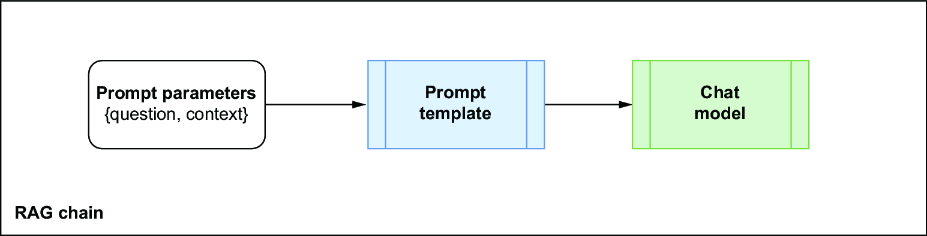

In [6]:
display(Image(filename="../images/CH07_F05_Infante2.png"))

## Build a simple RAG chain

Now we assemble the pieces into an actual chain, using LangChain's Expression Language (LCEL). The `|` operator pipes the output of one step into the input of the next, similar to a Unix pipeline:

```
{"context": retriever, "question": question_feeder} | rag_prompt | chatbot
```

Reading this left to right:
1. The input question is passed to both the `retriever` (which fetches relevant chunks) and `question_feeder` (which just passes the question through unchanged via `RunnablePassthrough`).
2. Both outputs are inserted into `rag_prompt`'s `{context}` and `{question}` placeholders.
3. The filled-in prompt is sent to the `chatbot` (our LLM) for a response.

This is the classic "retrieve, then generate" RAG pattern.

In [7]:
rag_prompt_template = """Use the following pieces of context
to answer the question at the end.
If you don't know the answer, just say that you don't know,
don't try to make up an answer.
Use three sentences maximum and keep the
answer as concise as possible.
{context}
Question: {question}
Helpful Answer:"""

rag_prompt = PromptTemplate.from_template(rag_prompt_template)

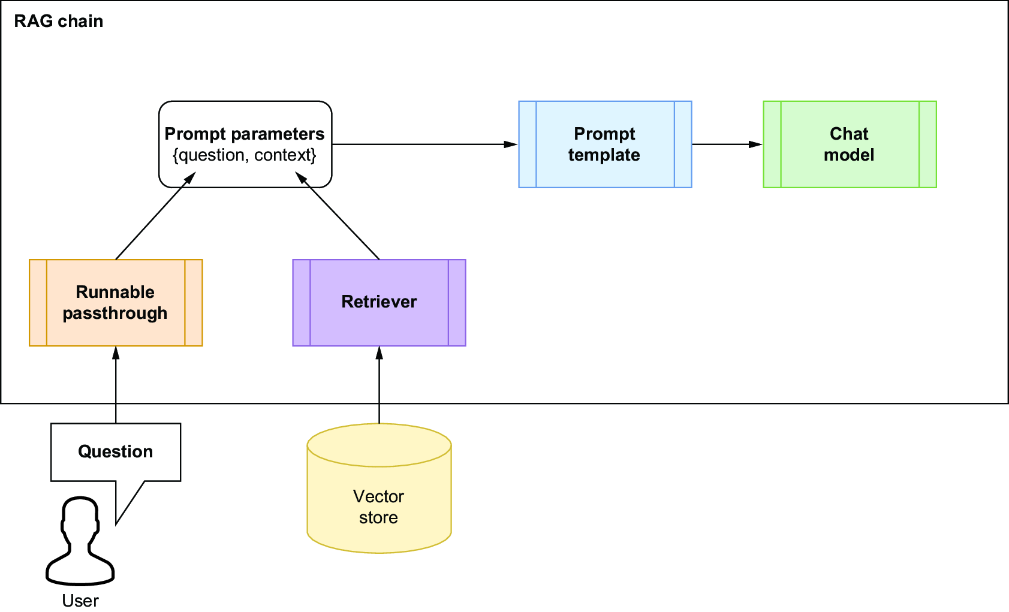

In [8]:
display(Image(filename="../images/CH07_F06_Infante2.png"))

In [9]:
retriever = vector_db.as_retriever()
question_feeder = RunnablePassthrough()
chatbot = llm

rag_chain = {"context": retriever,
             "question": question_feeder} | rag_prompt | chatbot

## Query the chain (no memory yet)

Let's ask the chain a question and see it correctly ground its answer in the retrieved documents. Then we'll immediately ask a natural follow-up question that only makes sense in light of the first one.

Watch what happens: the chain has no way of knowing what "they" or "it" refers to, because each call to `execute_chain` is completely independent — nothing from the previous turn is carried forward. This limitation is what we'll fix in the next section.

In [10]:
question = """Where was Poseidonia and who renamed
it to Paestum. Also tell me the source."""
answer = execute_chain(rag_chain, question)
print(answer.content)

Poseidonia was an ancient Greek city located in southern Italy near the west coast, 22 miles southeast of modern Salerno and 5 miles south of the Sele River. The Romans renamed it to Paestum when they took over the city in 273 BCE and established a Latin colony there. The source is from Encyclopaedia Britannica and Wikipedia articles on Paestum.


In [11]:
question = """And then, what they do?
Tell me only if you know.
Also tell me the source"""
answer = execute_chain(rag_chain, question)
print(answer.content)

I don't know. The provided context documents discuss the First Temple of Hera in Paestum, Parmenides, and sirens in Greek mythology, but none of them contain a clear narrative sequence that would answer "what they do" after a specific prior event. Without more context about who or what "they" refers to, I cannot provide an answer.


## Incorporating messages history

The follow-up question above failed because the chain has no memory of the previous turn — every invocation starts from a blank slate. To fix this, we:

1. Switch to a `ChatPromptTemplate` with a `{chat_history_messages}` placeholder, so past turns can be inserted into the prompt.
2. Keep a `ChatMessageHistory` object that accumulates human and AI messages across turns.
3. Wire it into the chain with `RunnableLambda`, which is how LCEL lets you inject arbitrary Python logic (here, "fetch the current history") as a step in the pipeline.
4. Use `execute_chain_with_memory`, which appends the new question and the model's answer to the shared history before/after each call.

Now the same kind of follow-up question can be answered correctly, because the model can see the earlier turns in the conversation.

In [12]:

rag_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """You are a helpful assistant, world-class 
            expert in Roman and Greek history, especially in towns 
            located in southern Italy. Provide interesting insights 
            on local history and recommend places to visit with 
            knowledgeable and engaging answers. Answer all questions 
            to the best of your ability, but only use what has been 
            provided in the context. If you don't know, just say 
            you don't know. Use three sentences maximum and keep 
            the answer as concise as possible."""),
        ("placeholder", "{chat_history_messages}"),
        ("assistant", "{retrieved_context}"),
        ("human", "{question}"),
    ])

retriever = vector_db.as_retriever()
question_feeder = RunnablePassthrough()
chatbot = llm
chat_history_memory = ChatMessageHistory()

def get_messages(x):
    return chat_history_memory.messages

rag_chain = {
    "retrieved_context": retriever, 
    "question": question_feeder,
    "chat_history_messages": RunnableLambda(get_messages)
} | rag_prompt | chatbot

def execute_chain_with_memory(chain, question):
    chat_history_memory.add_user_message(question)
    answer = chain.invoke(question)
    chat_history_memory.add_ai_message(answer)
    print(f'Full chat message history: {chat_history_memory.messages}\n\n')
    return answer

In [13]:
question = """Where was Poseidonia and who renamed
it to Paestum? Also tell me the source."""
answer = execute_chain_with_memory(rag_chain, question)
print(answer.content)

Full chat message history: [HumanMessage(content='Where was Poseidonia and who renamed\nit to Paestum? Also tell me the source.', additional_kwargs={}, response_metadata={}), AIMessage(content="Poseidonia was an ancient Greek city located in southern Italy near the west coast, about 22 miles southeast of modern Salerno. The Romans renamed it to Paestum when they took control of the city in 273 BCE and established a Latin colony there. The source is Encyclopaedia Britannica's article on Paestum.", additional_kwargs={}, response_metadata={'id': 'msg_011Cepm8P7fwgArKajczBZv7', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 1489, 'output_tokens': 79, 'output_tokens_details': None, 'server_tool_use': None,

Because `chat_history_memory` now holds the previous turn, the chain can resolve "they" from context and answer the follow-up correctly — this is memory playing out in action.

In [14]:
question = """And then what did they do?
Also tell me the source"""
answer = execute_chain_with_memory(rag_chain, question)
print(answer.content)

Full chat message history: [HumanMessage(content='Where was Poseidonia and who renamed\nit to Paestum? Also tell me the source.', additional_kwargs={}, response_metadata={}), AIMessage(content="Poseidonia was an ancient Greek city located in southern Italy near the west coast, about 22 miles southeast of modern Salerno. The Romans renamed it to Paestum when they took control of the city in 273 BCE and established a Latin colony there. The source is Encyclopaedia Britannica's article on Paestum.", additional_kwargs={}, response_metadata={'id': 'msg_011Cepm8P7fwgArKajczBZv7', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 1489, 'output_tokens': 79, 'output_tokens_details': None, 'server_tool_use': None,

## Fixing retrieval for follow-up questions

Look closely at the failed answer above: the model correctly resolved "they" as "the Romans" — proof the chat history *did* reach the prompt. It still said "I don't know" because the **retriever** never saw that resolution. In the chain, `retriever` is called with the raw follow-up text (`"And then what did they do?"`), which has almost no semantic overlap with the real topic, so the similarity search pulls back irrelevant chunks (temples, artifacts, etc.) instead of anything about Roman-era Paestum. Chat history reaching the *prompt* fixed pronoun resolution for generation, but retrieval is a separate step that never saw it.

The fix doesn't need a second LLM call to rewrite the question — we already *have* the history sitting in `chat_history_memory`. We just fold the most recent turn's text into the string we search with, so the embedding has real anchors ("Paestum", "Romans", "273 BCE") to match against instead of just "what did they do."

In [15]:
def get_retrieval_query(question):
    # Fold the most recent turn into the search text - no extra LLM call,
    # just give the embedding more of the surrounding names/dates than
    # the bare follow-up ("what did they do?") would provide on its own.
    recent_history = " ".join(m.content for m in chat_history_memory.messages[-2:])
    return f"{recent_history} {question}" if recent_history else question

rag_chain = {
    "retrieved_context": RunnableLambda(get_retrieval_query) | retriever,
    "question": question_feeder,
    "chat_history_messages": RunnableLambda(get_messages)
} | rag_prompt | chatbot

Let's re-run the same two-turn conversation with a fresh history and confirm the follow-up now resolves correctly — this time with only one LLM call per turn (the answer itself), same as the original chain.

In [16]:
chat_history_memory = ChatMessageHistory()  # reset for a clean before/after comparison

question = """Where was Poseidonia and who renamed
it to Paestum? Also tell me the source."""
answer = execute_chain_with_memory(rag_chain, question)
print(answer.content)

Full chat message history: [HumanMessage(content='Where was Poseidonia and who renamed\nit to Paestum? Also tell me the source.', additional_kwargs={}, response_metadata={}), AIMessage(content="Poseidonia was located in southern Italy near the west coast, about 22 miles southeast of modern Salerno and 5 miles south of the Sele River. The Romans renamed it to Paestum in 273 BCE when they took control of the city from the Lucanians and established a Latin colony there. The source is Encyclopaedia Britannica's article on Paestum and Wikipedia's entry on Paestum.", additional_kwargs={}, response_metadata={'id': 'msg_011Cepm8ca3dSWJqeuu7EWpQ', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 1490, 'output_to

In [17]:
question = """And then what did they do?
Also tell me the source"""
answer = execute_chain_with_memory(rag_chain, question)
print(answer.content)

Full chat message history: [HumanMessage(content='Where was Poseidonia and who renamed\nit to Paestum? Also tell me the source.', additional_kwargs={}, response_metadata={}), AIMessage(content="Poseidonia was located in southern Italy near the west coast, about 22 miles southeast of modern Salerno and 5 miles south of the Sele River. The Romans renamed it to Paestum in 273 BCE when they took control of the city from the Lucanians and established a Latin colony there. The source is Encyclopaedia Britannica's article on Paestum and Wikipedia's entry on Paestum.", additional_kwargs={}, response_metadata={'id': 'msg_011Cepm8ca3dSWJqeuu7EWpQ', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 1490, 'output_to